In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# Load all results
results = {}
for f in sorted(os.listdir('results_experiment')):
    if f.endswith('.json'):
        with open(os.path.join('results_experiment', f)) as fh:
            data = json.load(fh)
            results[data['meta_concept']] = data

# Filter out concepts that have no coordinate data
names = [n for n in results if results[n]['images_without_coords'] < results[n]['total_images']]
print(f'Loaded {len(results)} meta concepts, {len(names)} have coordinate data')

Loaded 13 meta concepts, 12 have coordinate data


In [3]:
def metrics_from_matrix(m):
    """Compute precision, recall, accuracy, F1 from a {tp,fp,tn,fn} dict."""
    tp, fp, tn, fn = m['tp'], m['fp'], m['tn'], m['fn']
    total = tp + fp + tn + fn
    acc = (tp + tn) / total if total > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {'accuracy': acc, 'recall': recall, 'precision': precision, 'f1': f1}


# Precompute metrics for all combinations
# metrics[concept_group][name][mask_state][subset] = {accuracy, recall, precision, f1}
metrics = {}
for group in ['manipulated', 'other_concepts']:
    metrics[group] = {}
    for n in names:
        metrics[group][n] = {}
        for mask_state in ['unmasked', 'masked']:
            metrics[group][n][mask_state] = {}
            for subset in ['all', 'same_pred', 'diff_pred']:
                metrics[group][n][mask_state][subset] = metrics_from_matrix(
                    results[n][group][mask_state][subset]
                )

print('Metrics computed')

Metrics computed


## Paper Figures: Precision & Recall Drop (Unmasked - Masked)

Combined bar plots with 4 bars per meta concept:
1. Same class pred - Masked body part (manipulated)
2. Same class pred - Other concepts
3. Diff class pred - Masked body part (manipulated)
4. Diff class pred - Other concepts

In [4]:
def combined_delta_plot(names, metrics, metric_name, title):
    """4-bar plot: same/diff class pred x manipulated/other concepts."""
    x = np.arange(len(names))
    width = 0.18
    gap = width * 0.5  # extra space between same-pred and diff-pred groups

    bars = [
        ('Same pred - Masked part',   'manipulated',    'same_pred',  '#1f77b4'),
        ('Same pred - Other concepts','other_concepts', 'same_pred',  '#aec7e8'),
        ('Diff pred - Masked part',   'manipulated',    'diff_pred',  '#d62728'),
        ('Diff pred - Other concepts','other_concepts', 'diff_pred',  '#ff9896'),
    ]

    offsets = [
        -1.5 * width - gap / 2,
        -0.5 * width - gap / 2,
         0.5 * width + gap / 2,
         1.5 * width + gap / 2,
    ]

    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.8), 5))
    for (label, group, subset, color), offset in zip(bars, offsets):
        deltas = [
            metrics[group][n]['unmasked'][subset][metric_name]
            - metrics[group][n]['masked'][subset][metric_name]
            for n in names
        ]
        ax.bar(x + offset, deltas, width, label=label, color=color)

    # Thin vertical separator between same-pred and diff-pred groups
    for xi in x:
        ax.axvline(x=xi, color='grey', linewidth=0.7, linestyle='--', alpha=0.4)

    ax.set_ylabel(f'{metric_name.capitalize()} drop (unmasked - masked)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

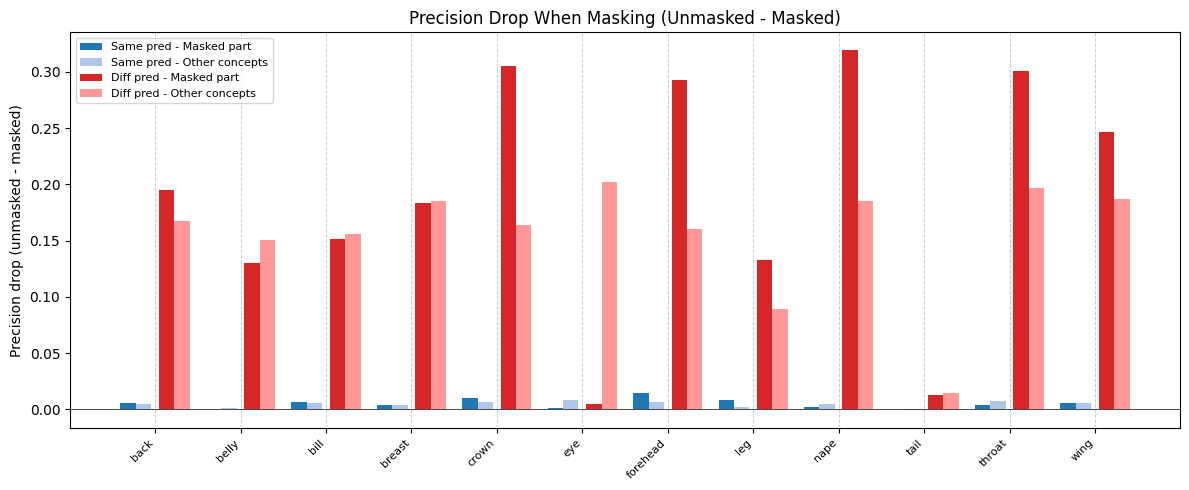

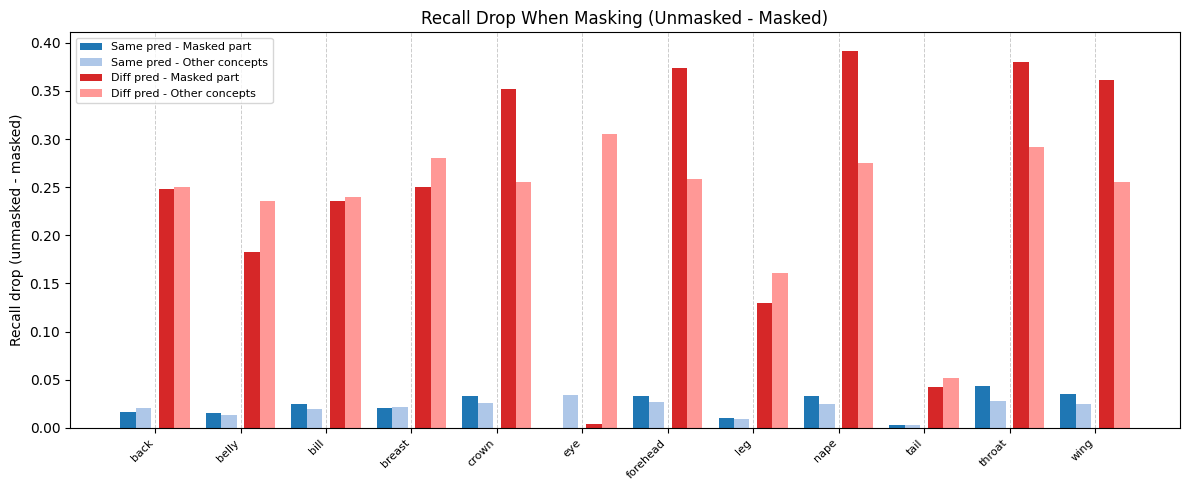

In [5]:
combined_delta_plot(names, metrics, 'precision',
                   'Precision Drop When Masking (Unmasked - Masked)')
combined_delta_plot(names, metrics, 'recall',
                   'Recall Drop When Masking (Unmasked - Masked)')

## Additional Plots: Absolute Values

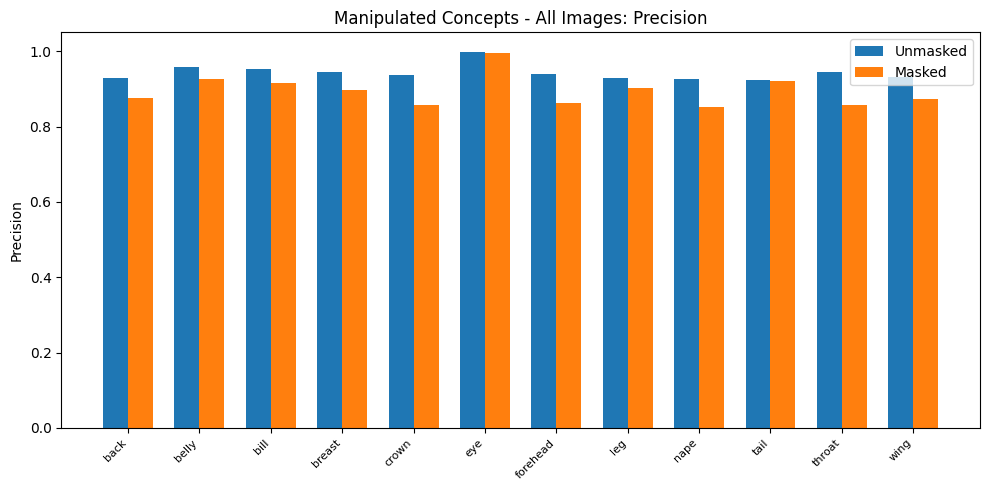

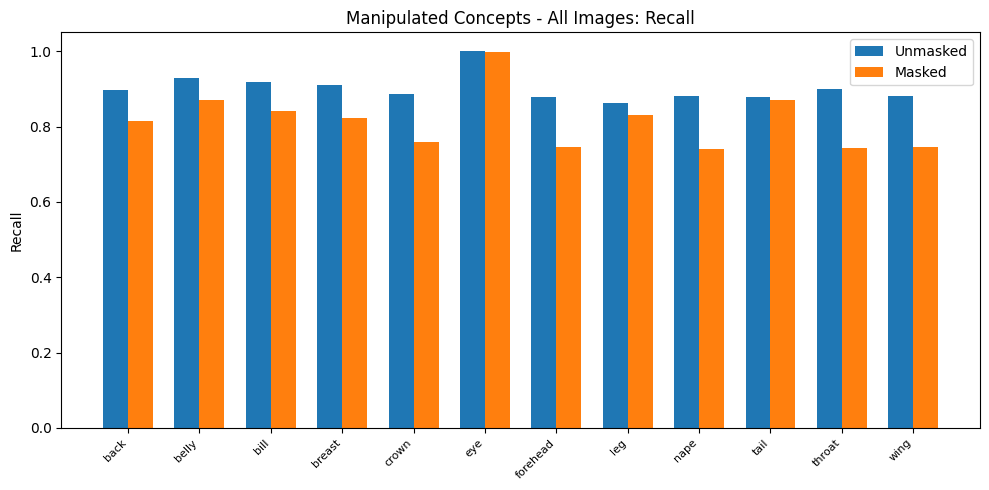

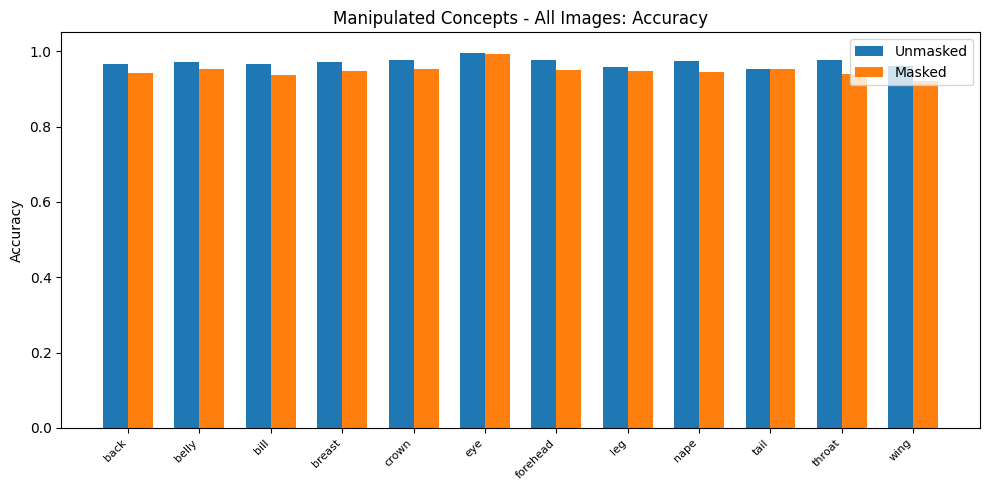

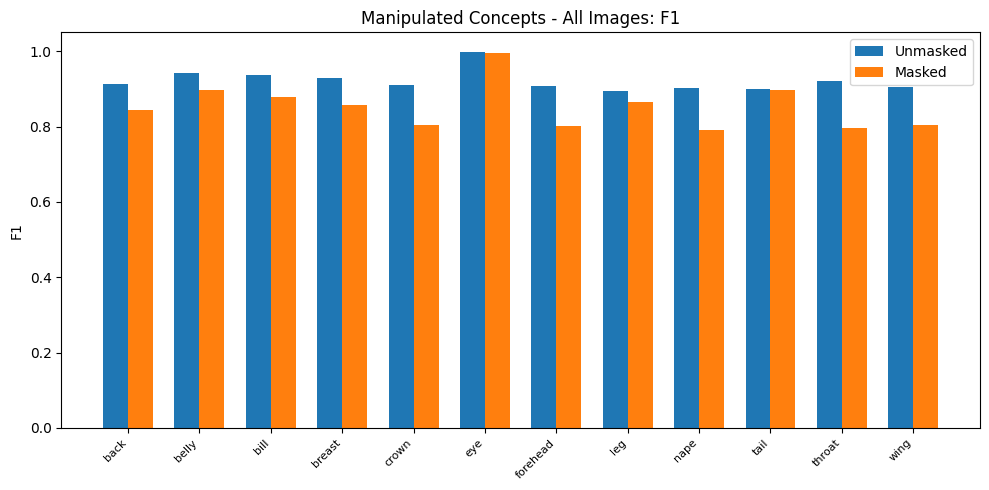

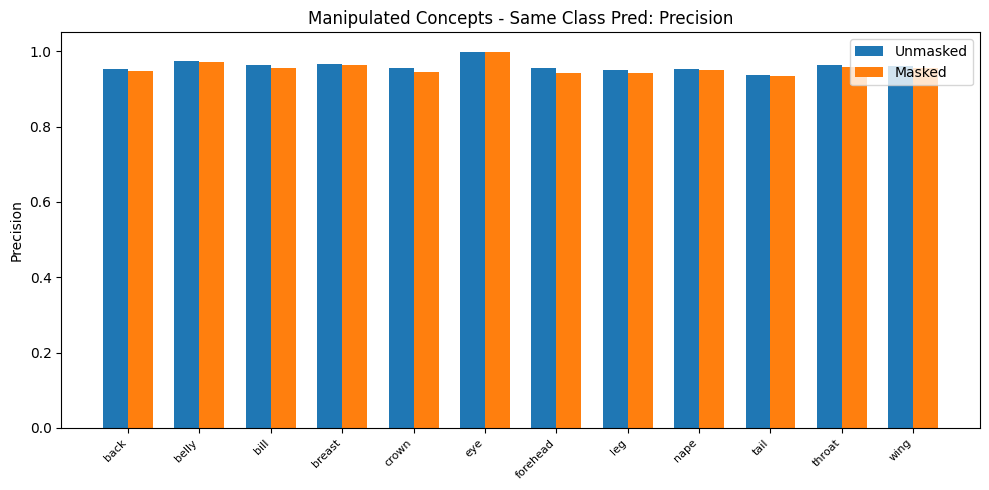

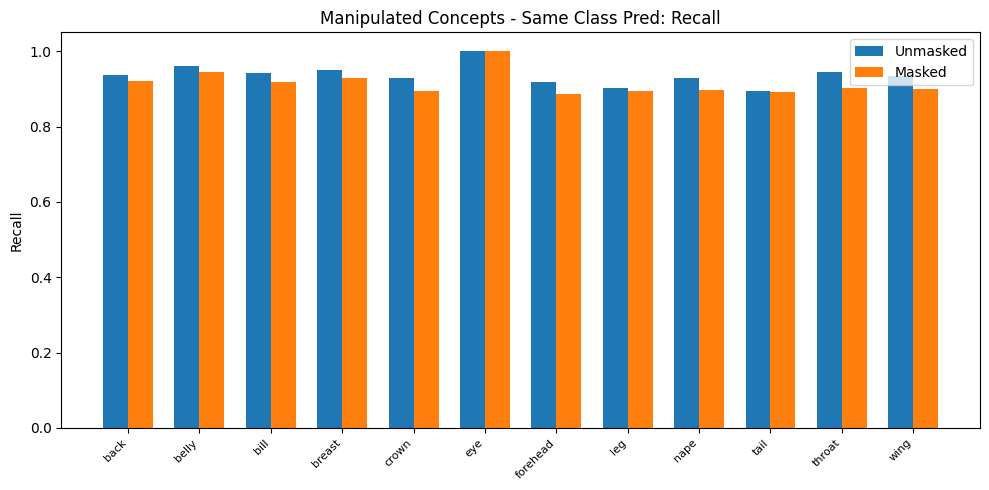

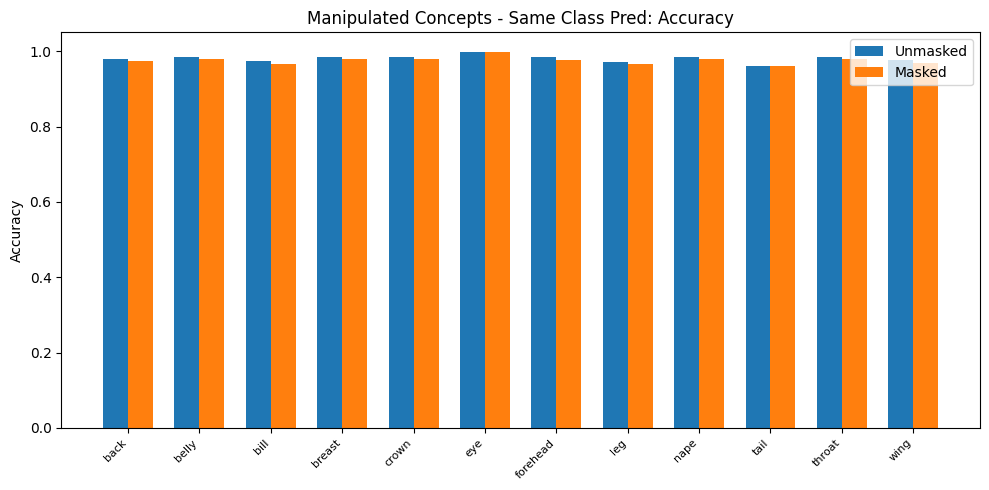

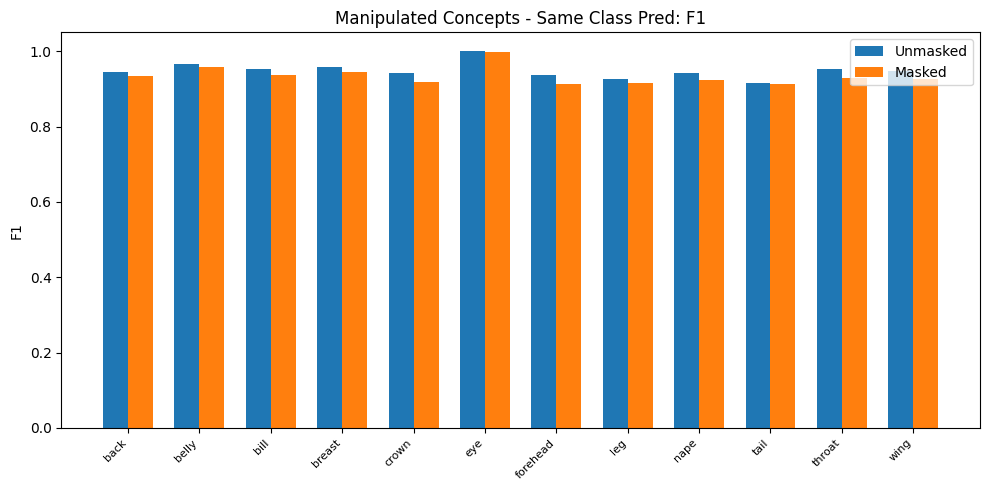

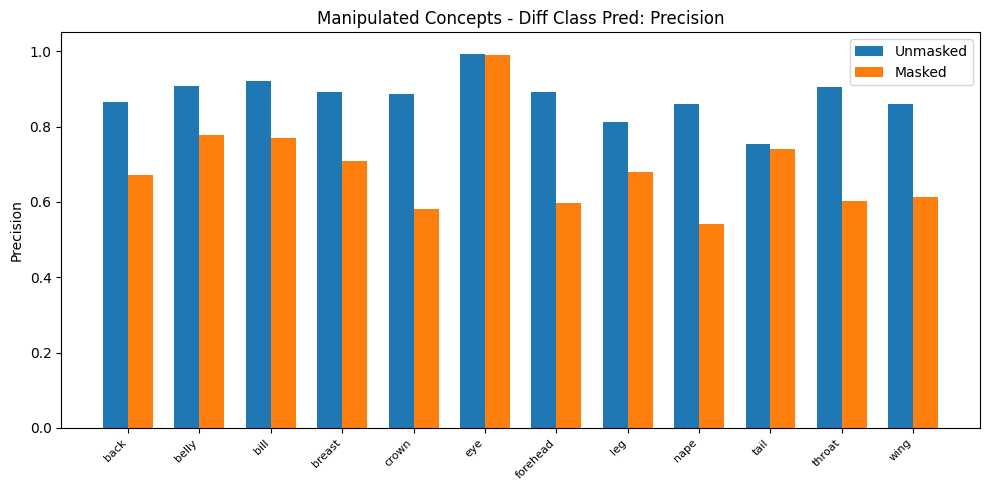

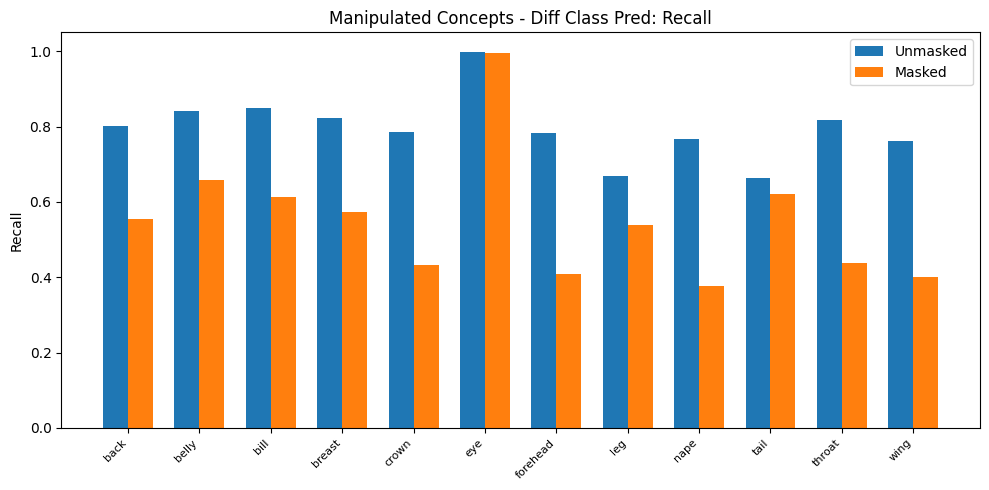

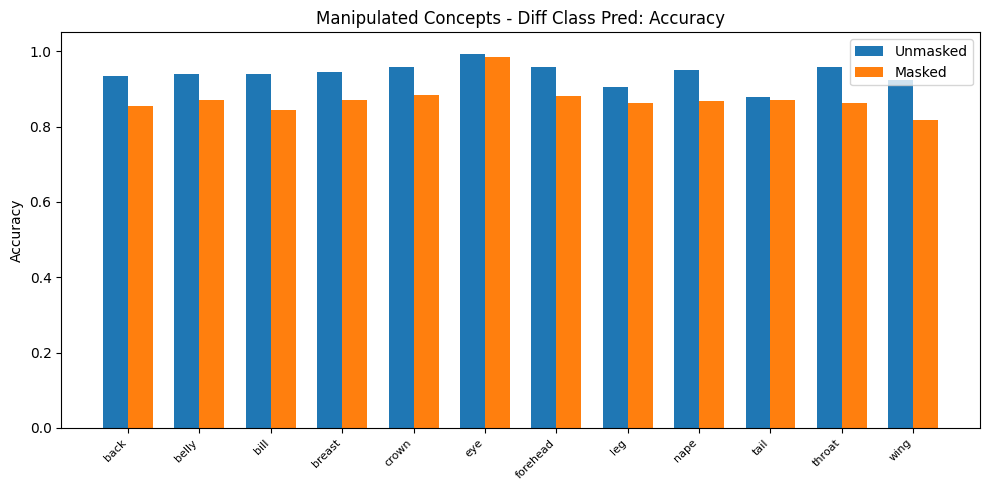

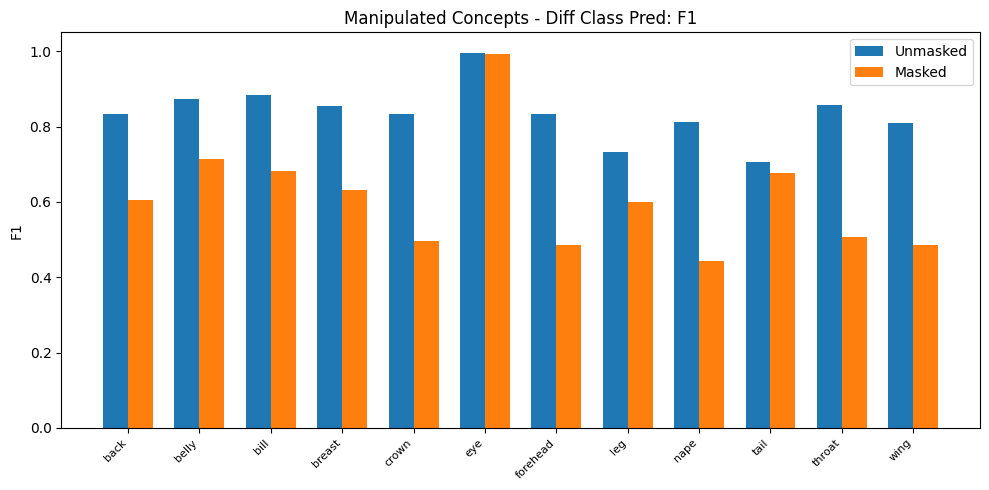

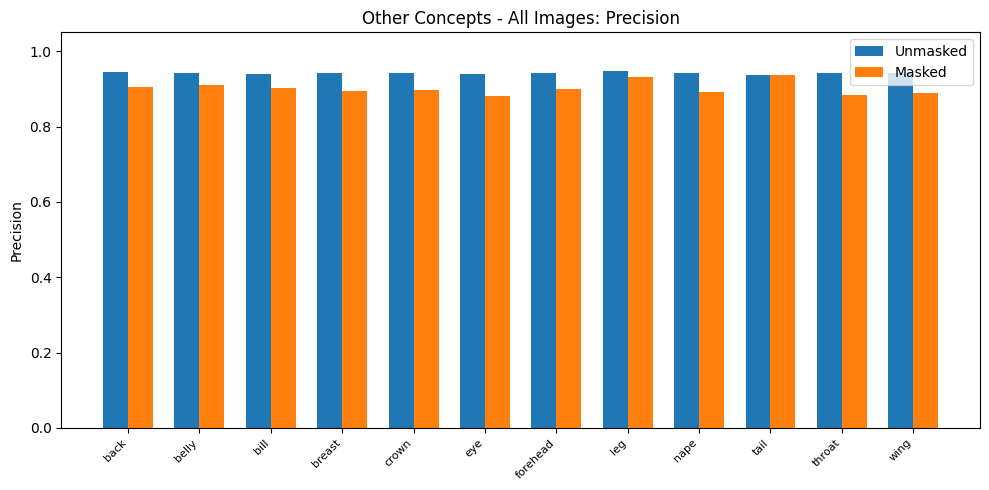

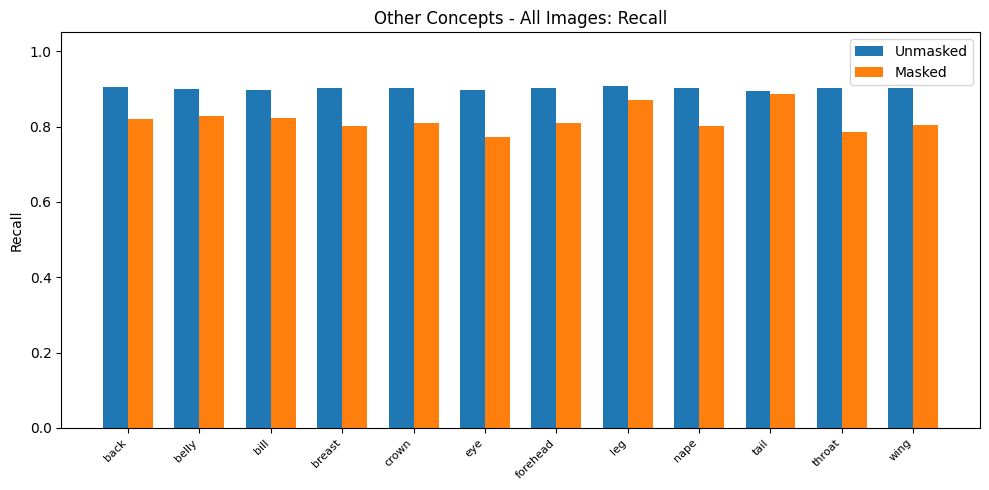

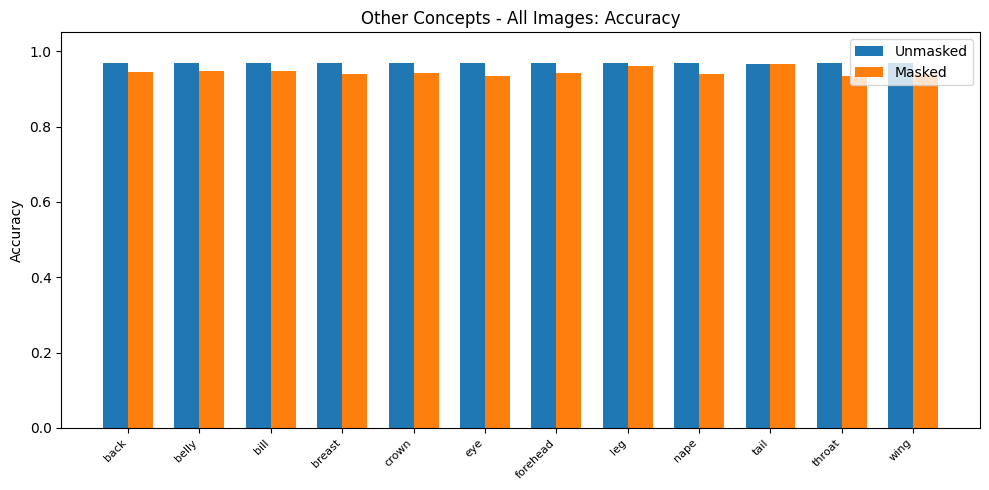

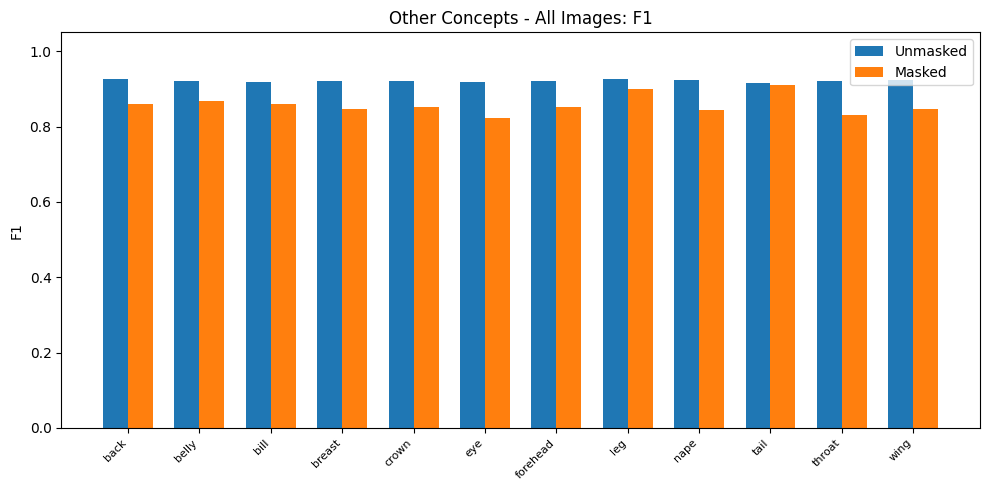

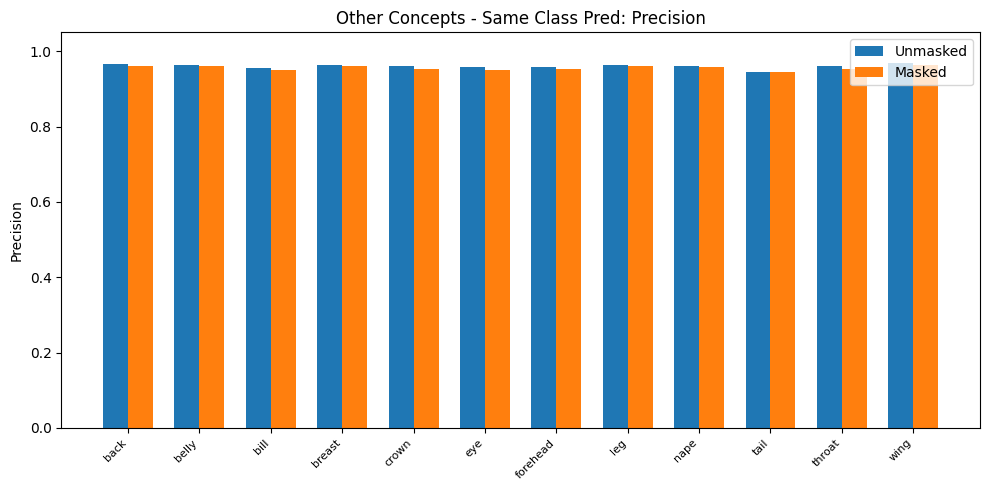

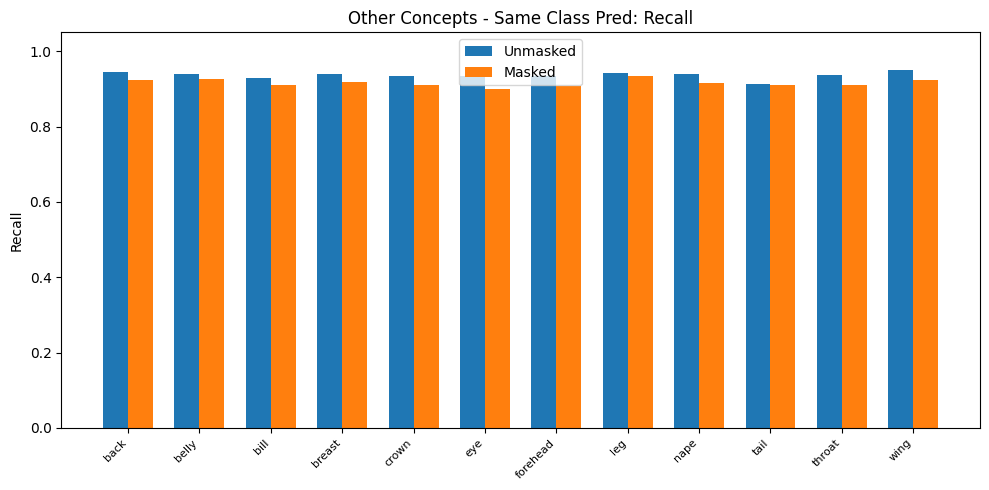

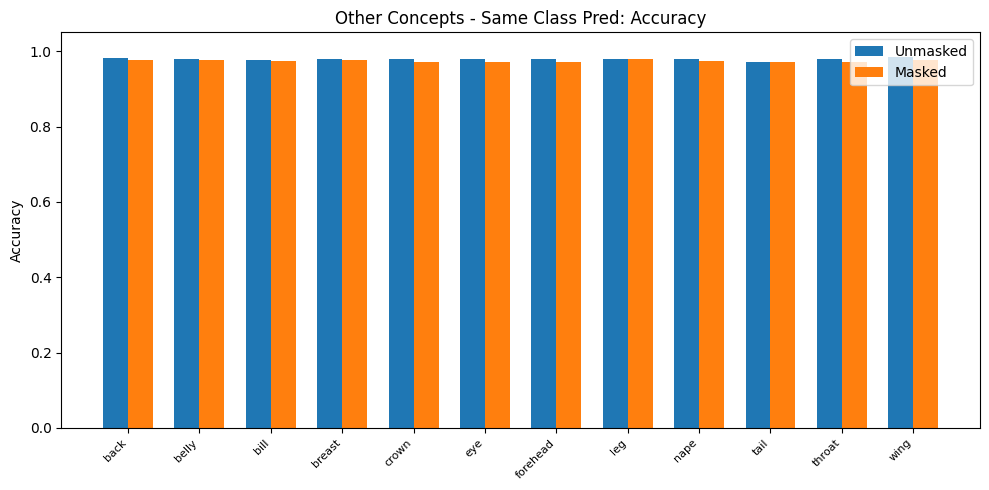

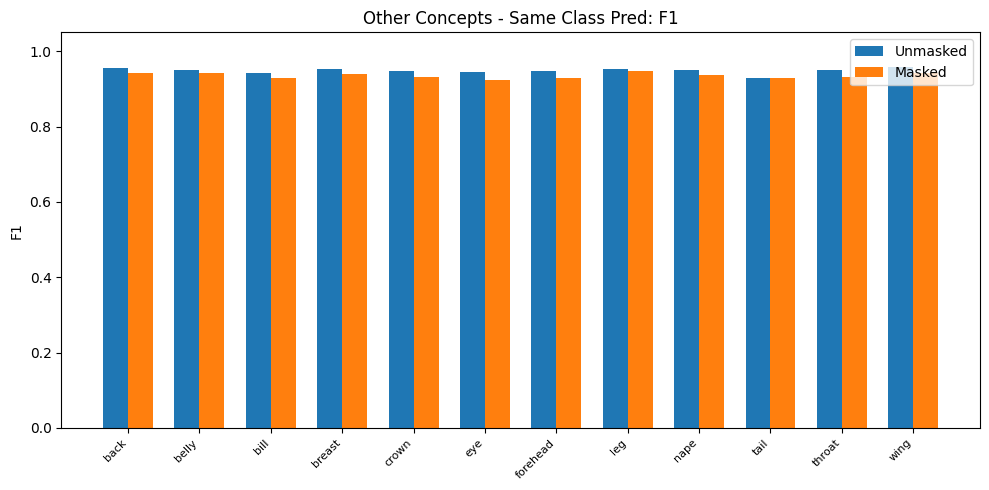

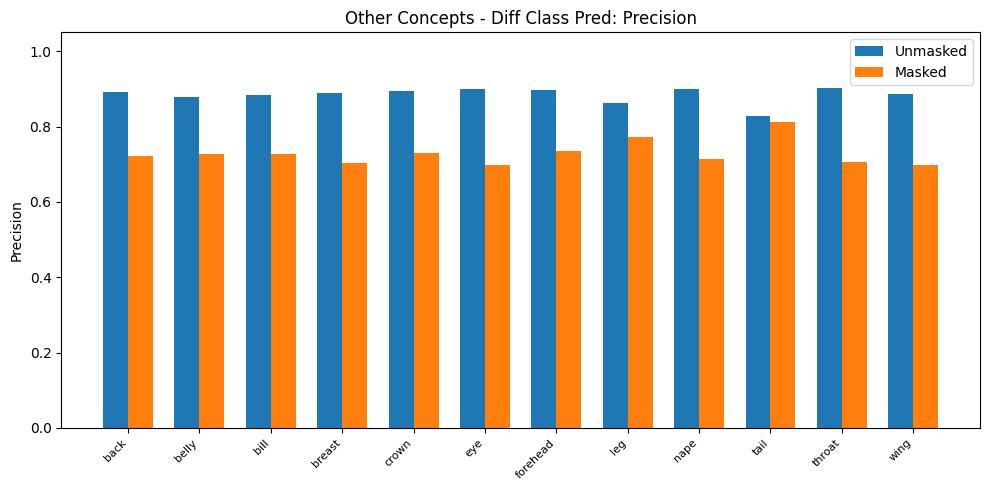

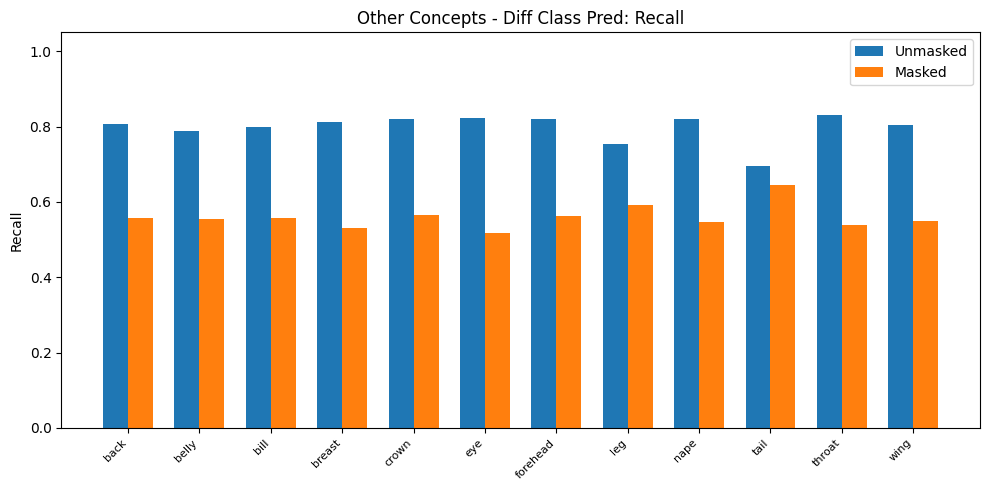

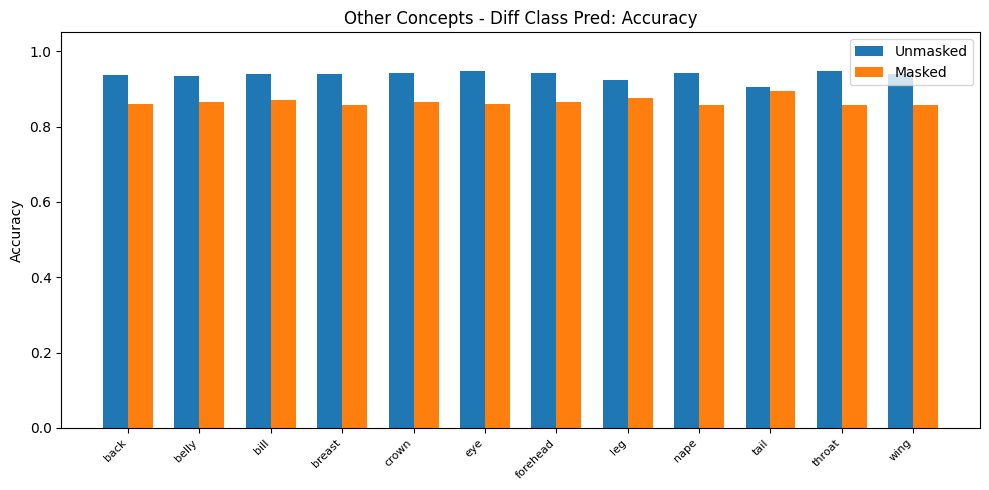

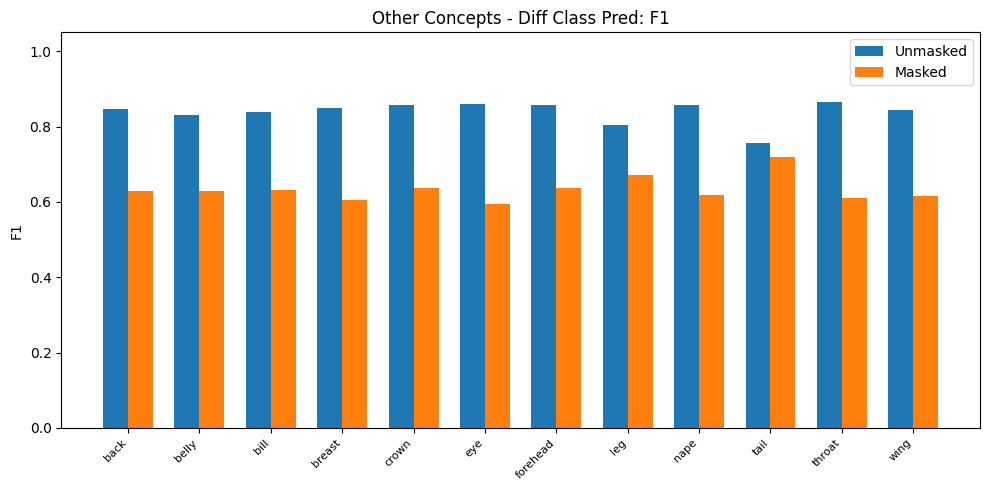

In [6]:
def abs_bar_plot(names, metrics, group, subset, metric_name, title):
    """Bar plot of absolute unmasked vs masked values."""
    x = np.arange(len(names))
    width = 0.35

    unmasked_vals = [metrics[group][n]['unmasked'][subset][metric_name] for n in names]
    masked_vals = [metrics[group][n]['masked'][subset][metric_name] for n in names]

    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
    ax.bar(x - width / 2, unmasked_vals, width, label='Unmasked')
    ax.bar(x + width / 2, masked_vals, width, label='Masked')
    ax.set_ylabel(metric_name.capitalize())
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


for group, group_label in [('manipulated', 'Manipulated'), ('other_concepts', 'Other')]:
    for subset, subset_label in [('all', 'All Images'), ('same_pred', 'Same Class Pred'), ('diff_pred', 'Diff Class Pred')]:
        for metric_name in ['precision', 'recall', 'accuracy', 'f1']:
            abs_bar_plot(names, metrics, group, subset, metric_name,
                         f'{group_label} Concepts - {subset_label}: {metric_name.capitalize()}')

## Class Accuracy

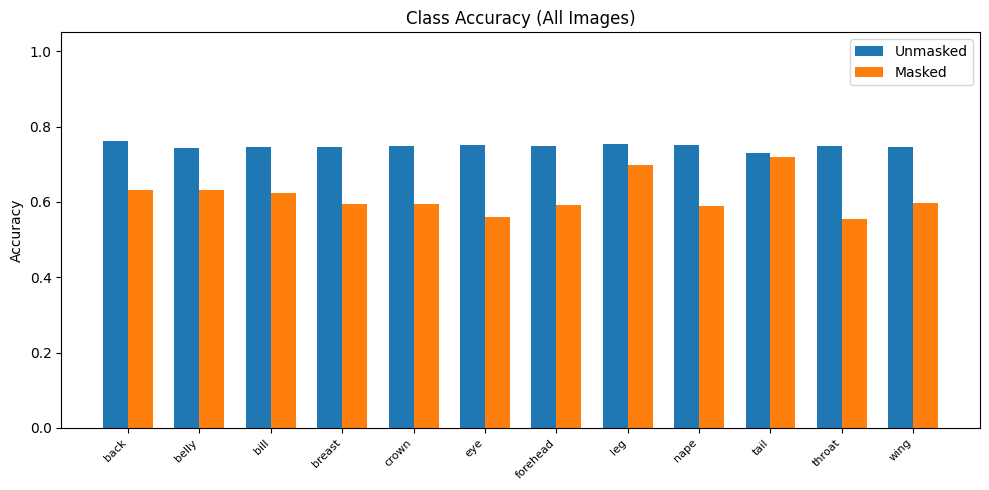

In [7]:
x = np.arange(len(names))
width = 0.35

orig_acc = [results[n]['class_accuracy']['unmasked']['correct'] / results[n]['class_accuracy']['unmasked']['total'] for n in names]
mask_acc = [results[n]['class_accuracy']['masked']['correct'] / results[n]['class_accuracy']['masked']['total'] for n in names]

fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
ax.bar(x - width / 2, orig_acc, width, label='Unmasked')
ax.bar(x + width / 2, mask_acc, width, label='Masked')
ax.set_ylabel('Accuracy')
ax.set_title('Class Accuracy (All Images)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Image Counts Summary

In [8]:
for n in names:
    r = results[n]
    used = r['same_class_pred_count'] + r['diff_class_pred_count']
    print(f"{n}: {r['same_class_pred_count']} same, {r['diff_class_pred_count']} diff, "
          f"{r['images_without_coords']} no coords ({used}/{r['total_images']} used)")

back: 3181 same, 1206 diff, 1407 no coords (4387/5794 used)
belly: 3747 same, 1325 diff, 722 no coords (5072/5794 used)
bill: 3846 same, 1260 diff, 688 no coords (5106/5794 used)
breast: 3711 same, 1603 diff, 480 no coords (5314/5794 used)
crown: 3676 same, 1473 diff, 645 no coords (5149/5794 used)
eye: 3551 same, 1734 diff, 509 no coords (5285/5794 used)
forehead: 3665 same, 1465 diff, 664 no coords (5130/5794 used)
leg: 3876 same, 866 diff, 1052 no coords (4742/5794 used)
nape: 3806 same, 1654 diff, 334 no coords (5460/5794 used)
tail: 3525 same, 320 diff, 1949 no coords (3845/5794 used)
throat: 3702 same, 1867 diff, 225 no coords (5569/5794 used)
wing: 3848 same, 1756 diff, 190 no coords (5604/5794 used)


## LaTeX Table (Appendix)

Full table with precision, recall, accuracy for all groups/subsets.

In [9]:
def generate_latex_reports(names, results):
    """Generate per-meta-concept LaTeX reports with confusion matrices (masked only)."""
    lines = []
    # Packages comment
    lines.append('% Requires: \\usepackage{booktabs}, \\usepackage[table]{xcolor}')
    lines.append('')

    for n in names:
        r = results[n]
        total = r['total_images']
        skipped = r['images_without_coords']
        same = r['same_class_pred_count']
        diff = r['diff_class_pred_count']

        lines.append(f'\\subsection{{{n.replace("_", " ").title()}}}')
        lines.append('')

        # Image count summary
        lines.append(f'Total images: {total}, skipped (no coords): {skipped}, '
                      f'same prediction: {same}, different prediction: {diff}.')
        lines.append('')

        # 4 confusion matrices in 2x2 grid (masked only)
        matrix_configs = [
            ('Same pred --- Masked part',    'manipulated',    'same_pred'),
            ('Same pred --- Other concepts', 'other_concepts', 'same_pred'),
            ('Diff pred --- Masked part',    'manipulated',    'diff_pred'),
            ('Diff pred --- Other concepts', 'other_concepts', 'diff_pred'),
        ]

        lines.append('\\noindent')
        for i, (label, group, subset) in enumerate(matrix_configs):
            m = r[group]['masked'][subset]
            tp, fp, tn, fn = m['tp'], m['fp'], m['tn'], m['fn']
            total_m = tp + fp + tn + fn

            def fmt(val):
                pct = 100 * val / total_m if total_m > 0 else 0
                return f'{val} ({pct:.1f}\\%)'

            if i % 2 == 0:
                lines.append('\\begin{minipage}[t]{0.48\\textwidth}')
            else:
                lines.append('\\hfill')
                lines.append('\\begin{minipage}[t]{0.48\\textwidth}')

            lines.append('{\\scriptsize')
            lines.append(f'\\textbf{{{label}}}')
            lines.append('')
            lines.append('\\begin{tabular}{l l l}')
            lines.append('\\toprule')
            lines.append(' & Actual Pos & Actual Neg \\\\')
            lines.append('\\midrule')
            lines.append(f'Pred Pos & \\cellcolor{{green!20}} TP: {fmt(tp)} & \\cellcolor{{red!15}} FP: {fmt(fp)} \\\\')
            lines.append(f'Pred Neg & \\cellcolor{{red!15}} FN: {fmt(fn)} & \\cellcolor{{green!20}} TN: {fmt(tn)} \\\\')
            lines.append('\\bottomrule')
            lines.append('\\end{tabular}')
            lines.append('}')  # close \scriptsize
            lines.append('\\end{minipage}')

            if i % 2 == 1:
                lines.append('')
                lines.append('\\vspace{0.5em}')
                lines.append('')

        lines.append('\\clearpage')
        lines.append('')

    return '\n'.join(lines)


latex = generate_latex_reports(names, results)
print(latex)

% Requires: \usepackage{booktabs}, \usepackage[table]{xcolor}

\subsection{Back}

Total images: 5794, skipped (no coords): 1407, same prediction: 3181, different prediction: 1206.

\noindent
\begin{minipage}[t]{0.48\textwidth}
{\scriptsize
\textbf{Same pred --- Masked part}

\begin{tabular}{l l l}
\toprule
 & Actual Pos & Actual Neg \\
\midrule
Pred Pos & \cellcolor{green!20} TP: 5043 (17.6\%) & \cellcolor{red!15} FP: 286 (1.0\%) \\
Pred Neg & \cellcolor{red!15} FN: 440 (1.5\%) & \cellcolor{green!20} TN: 22860 (79.8\%) \\
\bottomrule
\end{tabular}
}
\end{minipage}
\hfill
\begin{minipage}[t]{0.48\textwidth}
{\scriptsize
\textbf{Same pred --- Other concepts}

\begin{tabular}{l l l}
\toprule
 & Actual Pos & Actual Neg \\
\midrule
Pred Pos & \cellcolor{green!20} TP: 62878 (19.2\%) & \cellcolor{red!15} FP: 2637 (0.8\%) \\
Pred Neg & \cellcolor{red!15} FN: 5219 (1.6\%) & \cellcolor{green!20} TN: 256909 (78.4\%) \\
\bottomrule
\end{tabular}
}
\end{minipage}

\vspace{0.5em}

\begin{minipage}[t

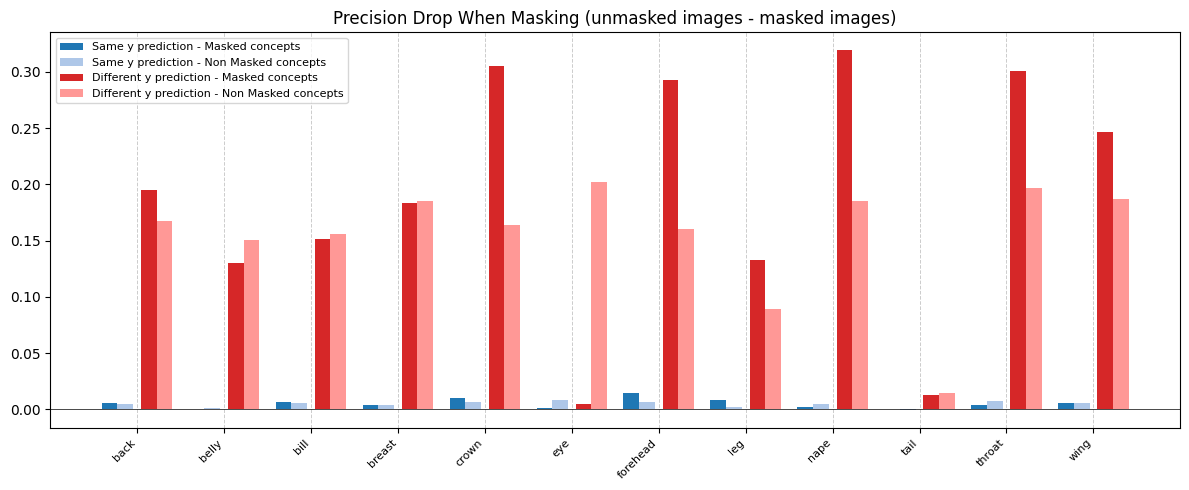

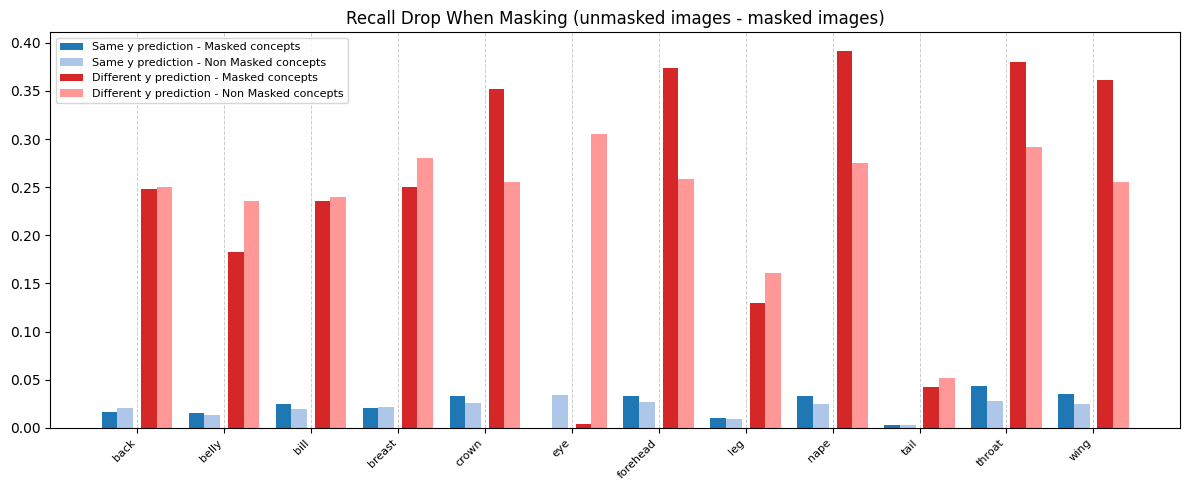

In [32]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# Load all results
results = {}
for f in sorted(os.listdir('results_experiment1')):
    if f.endswith('.json'):
        with open(os.path.join('results_experiment1', f)) as fh:
            data = json.load(fh)
            results[data['meta_concept']] = data

names = [n for n in results if results[n]['images_without_coords'] < results[n]['total_images']]

def metrics_from_matrix(m):
    tp, fp, tn, fn = m['tp'], m['fp'], m['tn'], m['fn']
    total = tp + fp + tn + fn
    acc = (tp + tn) / total if total > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {'accuracy': acc, 'recall': recall, 'precision': precision, 'f1': f1}

metrics = {}
for group in ['manipulated', 'other_concepts']:
    metrics[group] = {}
    for n in names:
        metrics[group][n] = {}
        for mask_state in ['unmasked', 'masked']:
            metrics[group][n][mask_state] = {}
            for subset in ['all', 'same_pred', 'diff_pred']:
                metrics[group][n][mask_state][subset] = metrics_from_matrix(
                    results[n][group][mask_state][subset]
                )

def combined_delta_plot(names, metrics, metric_name, title):
    """4-bar plot: same/diff class pred x manipulated/other concepts."""
    x = np.arange(len(names))
    width = 0.18
    gap = width * 0.5

    bars = [
        ('Same y prediction - Masked concepts',   'manipulated',    'same_pred',  '#1f77b4'),
        ('Same y prediction - Non Masked concepts','other_concepts', 'same_pred',  '#aec7e8'),
        ('Different y prediction - Masked concepts',   'manipulated',    'diff_pred',  '#d62728'),
        ('Different y prediction - Non Masked concepts','other_concepts', 'diff_pred',  '#ff9896'),
    ]

    offsets = [
        -1.5 * width - gap / 2,
        -0.5 * width - gap / 2,
         0.5 * width + gap / 2,
         1.5 * width + gap / 2,
    ]

    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.8), 5))
    for (label, group, subset, color), offset in zip(bars, offsets):
        deltas = [
            metrics[group][n]['unmasked'][subset][metric_name]
            - metrics[group][n]['masked'][subset][metric_name]
            for n in names
        ]
        ax.bar(x + offset, deltas, width, label=label, color=color)

    for xi in x:
        ax.axvline(x=xi, color='grey', linewidth=0.7, linestyle='--', alpha=0.4)

    #ax.set_ylabel(f'{metric_name.capitalize()} drop (unmasked images - masked images)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

combined_delta_plot(names, metrics, 'precision', 'Precision Drop When Masking (unmasked images - masked images)')
combined_delta_plot(names, metrics, 'recall', 'Recall Drop When Masking (unmasked images - masked images)')

In [26]:
def generate_latex_reports(names, results):
    """Generate per-meta-concept LaTeX reports with confusion matrices (masked only)."""
    lines = []
    # Packages comment

    for n in names:
        r = results[n]
        total = r['total_images']
        skipped = r['images_without_coords']
        same = r['same_class_pred_count']
        diff = r['diff_class_pred_count']

        lines.append(f'\\subsection{{{n.replace("_", " ").title()}}}')
        lines.append('')

        # Image count summary
        
        lines.append(f'Images with same prediction: {same}: {same/total*100:.0f}\\% \\\\ ')
        lines.append(f'Images with different prediction: {diff}: {diff/total*100:.0f}\\% \\\\ ')
        lines.append(f'Images skipped due to missing coordinates: {skipped}: {skipped/total*100:.0f}\\% \\\\ ')
        
        lines.append('')

        # 4 confusion matrices in 2x2 grid (masked only)
        matrix_configs = [
            ('Same y prediction --- Masked concepts',    'manipulated',    'same_pred'),
            ('Same y prediction --- Non Masked concepts', 'other_concepts', 'same_pred'),
            ('Diff y prediction --- Masked concepts',    'manipulated',    'diff_pred'),
            ('Diff y prediction --- Non Masked concepts', 'other_concepts', 'diff_pred'),
        ]

        lines.append('\\noindent')
        for i, (label, group, subset) in enumerate(matrix_configs):
            m = r[group]['masked'][subset]
            tp, fp, tn, fn = m['tp'], m['fp'], m['tn'], m['fn']
            total_m = tp + fp + tn + fn

            def fmt(val):
                pct = 100 * val / total_m if total_m > 0 else 0
                return f'{val} ({pct:.0f}\\%)'



            lines.append('{\\scriptsize')
            lines.append(f'\\textbf{{{label}}}')
            lines.append('')
            lines.append('\\begin{tabular}{l l l}')
            lines.append('\\toprule')
            lines.append(' & Actual Positive & Actual Negative \\\\')
            lines.append('\\midrule')
            lines.append(f'Pred Positive & \\cellcolor{{green!20}} TP: {fmt(tp)} & \\cellcolor{{red!15}} FP: {fmt(fp)} \\\\')
            lines.append(f'Pred Negative & \\cellcolor{{red!15}} FN: {fmt(fn)} & \\cellcolor{{green!20}} TN: {fmt(tn)} \\\\')
            lines.append('\\bottomrule')
            lines.append('\\end{tabular}')
            lines.append('}')  # close \scriptsize


            lines.append('')
            lines.append('\\vspace{0.5em}')
            lines.append('')

        lines.append('')

    return '\n'.join(lines)


latex = generate_latex_reports(names, results)
print(latex)


\subsection{Back}

Images with same prediction: 3181: 55\% \\ 
Images with different prediction: 1206: 21\% \\ 
Images skipped due to missing coordinates: 1407: 24\% \\ 

\noindent
{\scriptsize
\textbf{Same y prediction --- Masked concepts}

\begin{tabular}{l l l}
\toprule
 & Actual Positive & Actual Negative \\
\midrule
Pred Positive & \cellcolor{green!20} TP: 5043 (18\%) & \cellcolor{red!15} FP: 286 (1\%) \\
Pred Negative & \cellcolor{red!15} FN: 440 (2\%) & \cellcolor{green!20} TN: 22860 (80\%) \\
\bottomrule
\end{tabular}
}

\vspace{0.5em}

{\scriptsize
\textbf{Same y prediction --- Non Masked concepts}

\begin{tabular}{l l l}
\toprule
 & Actual Positive & Actual Negative \\
\midrule
Pred Positive & \cellcolor{green!20} TP: 62878 (19\%) & \cellcolor{red!15} FP: 2637 (1\%) \\
Pred Negative & \cellcolor{red!15} FN: 5219 (2\%) & \cellcolor{green!20} TN: 256909 (78\%) \\
\bottomrule
\end{tabular}
}

\vspace{0.5em}

{\scriptsize
\textbf{Diff y prediction --- Masked concepts}

\begin{tab